# **--------------------------------------------------**

# **code for new dataset**

In [1]:
import os

data_dir = "/content/drive/MyDrive"

print(" Exists:", os.path.exists(data_dir))
print(" Subfolders:", os.listdir(data_dir) if os.path.exists(data_dir) else "No directory")


 Exists: True
 Subfolders: ['stars.csv', 'movies.csv', 'people.csv', 'Student Information.docx', 'LockDownBrowser-2-0-7-06.exe', 'Copy of Nesreen - Critical Thinking F21.docx', 'Test.gdoc', 'Meet Recordings', 'NGN 110_02(5).mcworld', 'Copy of Minecraft Final Report.gdoc', 'Copy of NGN 110_02(clinic done).mcworld', 'Copy of Presentation Script.gdoc', 'Nesreen Assignment 4 Draft Paper books v eBooks.docx', 'Practice summary( 1. Nesreen rahmeh 2. Hoda Tolba 3. Shaikha Aljaberi 4. Lina Jadallah).gdoc', 'g00089853@aus.edu.gdoc', 'Untitled document (12).gdoc', 'Reading activity- Nesreen Rahmeh.gdoc', 'contrast essay - Nesreen Rahmeh WRI101 sec 15.gdoc', 'script.gdoc', 'Untitled document (11).gdoc', 'Untitled document (10).gdoc', 'development of technology and its effects.gdoc', 'Planning Worksheet-Nesreen Rahmeh.gdoc', 'summary respones -nesreen rahmeh.gdoc', 'planning sheet-Nesreen Rahmeh.gdoc', 'Untitled document (9).gdoc', 'argumantative essay-nesreen rahmeh.gdoc', 'mini paper.gdoc', 'Psy

In [2]:
import os

data_dir = "/content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar"
java_files = []

for root, dirs, files in os.walk(data_dir):
    for file in files:
        if file.endswith(".java"):
            java_files.append(os.path.join(root, file))

if java_files:
    print(f" Found {len(java_files)} Java files:")
    for path in java_files[:10]:
        print("  -", path)
else:
    print(" No Java files found!")

 No Java files found!


In [3]:
!pip install patool

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 2.6 MB/s eta 0:00:00


In [4]:
import patoolib

# Extract the RAR file first
patoolib.extract_archive("/content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar", outdir="/content/extracted_data")

# Then point to the extracted directory
data_dir = "/content/extracted_data/partitioned_results_TFTPWMN1Complete"

INFO patool: Extracting /content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar ...
INFO:patool:Extracting /content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar ...
INFO patool: ... creating output directory `/content/extracted_data'.
INFO:patool:... creating output directory `/content/extracted_data'.
INFO patool: running /usr/bin/unrar x -kb -or -- /content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar
INFO:patool:running /usr/bin/unrar x -kb -or -- /content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar
INFO patool: ... /content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar extracted to `/content/extracted_data'.
INFO:patool:... /content/drive/MyDrive/partitioned_results_TFTPWMN1Complete.rar extracted to `/content/extracted_data'.


In [5]:
import os
import csv
import itertools
from collections import defaultdict

data_dir = "/content/extracted_data/partitioned_results_TFTPWMN1Complete"  # e.g., "./MutantDataset/"
code_db = []
code_lookup = {}
pairwise = []
mutant_id_to_set = {}
set_to_ids = defaultdict(list)

# Step 1: Generate code_db.csv
for set_folder in sorted(os.listdir(data_dir)):
    set_path = os.path.join(data_dir, set_folder)
    if not os.path.isdir(set_path):
        continue

    for file in os.listdir(set_path):
        if file.endswith(".java") and file.startswith("M"):
            code_id = int(file[1:-5])  # Remove 'M' and '.java'
            file_path = os.path.join(set_path, file)
            with open(file_path, "r", encoding="utf-8") as f:
                code = f.read()
            code_db.append({"id": code_id, "code": code})
            code_lookup[code_id] = code
            mutant_id_to_set[code_id] = set_folder
            set_to_ids[set_folder].append(code_id)

# Step 2: Generate pairwise.csv
pair_id = 0

# (a) Add all equivalent pairs (label = 1)
for mutant_ids in set_to_ids.values():
    for combo in itertools.combinations(mutant_ids, 2):
        pairwise.append({
            "id": pair_id,
            "code_id_1": combo[0],
            "code_id_2": combo[1],
            "label": 1
        })
        pair_id += 1

# (b) Add non-equivalent pairs (label = 0) — one from each different set
all_sets = list(set_to_ids.keys())
for i in range(len(all_sets)):
    for j in range(i + 1, len(all_sets)):
        set_i = all_sets[i]
        set_j = all_sets[j]
        for id_i in set_to_ids[set_i]:
            for id_j in set_to_ids[set_j]:
                pairwise.append({
                    "id": pair_id,
                    "code_id_1": id_i,
                    "code_id_2": id_j,
                    "label": 0
                })
                pair_id += 1

# Step 3: Save code_db.csv
with open("code_db.csv", "w", newline='', encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["id", "code"])
    writer.writeheader()
    writer.writerows(code_db)

# Step 4: Save pairwise.csv
with open("pairwise.csv", "w", newline='', encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=["id", "code_id_1", "code_id_2", "label"])
    writer.writeheader()
    writer.writerows(pairwise)


 All files generated: code_db.csv, pairwise.csv, generated_mutant_pairs.csv
 Total Pairs: 10153
   id  code_id_1  code_id_2  equivalent  \
0   0         54         19           1   
1   1         54         99           1   
2   2         19         99           1   
3   3        121        122           1   
4   4         94         97           1   

                                             mutant1  \
0  public class TFTP {\n\n\tString input;\n\n\tpu...   
1  public class TFTP {\n\n\tString input;\n\n\tpu...   
2  public class TFTP {\n\n\tString input;\n\n\tpu...   
3  public class TFTP {\n\n\tString input;\n\n\tpu...   
4  public class TFTP {\n\n\tString input;\n\n\tpu...   

                                             mutant2  
0  public class TFTP {\n\n\tString input;\n\n\tpu...  
1  public class TFTP {\n\n\tString input;\n\n\tpu...  
2  public class TFTP {\n\n\tString input;\n\n\tpu...  
3  public class TFTP {\n\n\tString input;\n\n\tpu...  
4  public class TFTP {\n\n\tStrin

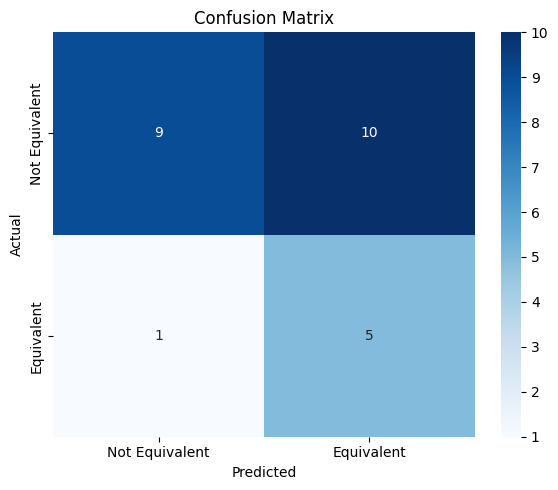

In [ ]:
#  Required Libraries
import os
import csv
import itertools
from collections import defaultdict
import pandas as pd
import openai
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


#  Set your OpenAI API key
openai.api_key = 'API KEY'  # <-- Put your key here

##  Correct root folder path
data_dir = "/content/extracted_data/partitioned_results_TFTPWMN1Complete"

code_db = []
code_lookup = {}
pairwise = []
mutant_id_to_set = {}
set_to_ids = defaultdict(list)

# Step 1: Generate code_db.csv
for set_folder in sorted(os.listdir(data_dir)):
    set_path = os.path.join(data_dir, set_folder)
    if not os.path.isdir(set_path):
        continue

    for file in os.listdir(set_path):
        if file.endswith(".java") and file.startswith("M"):
            try:
                code_id = int(file[1:-5])  # Remove 'M' and '.java'
            except:
                continue  # Skip malformed filenames
            file_path = os.path.join(set_path, file)
            with open(file_path, "r", encoding="utf-8") as f:
                code = f.read().strip()
            if code:  # Skip empty files
                code_db.append({"id": code_id, "code": code})
                code_lookup[code_id] = code
                mutant_id_to_set[code_id] = set_folder
                set_to_ids[set_folder].append(code_id)

# Step 2: Generate pairwise equivalence data
pair_id = 0

# (a) Add all equivalent pairs (same set)
for mutant_ids in set_to_ids.values():
    for combo in itertools.combinations(mutant_ids, 2):
        pairwise.append({
            "id": pair_id,
            "code_id_1": combo[0],
            "code_id_2": combo[1],
            "label": 1
        })
        pair_id += 1

# (b) Add non-equivalent pairs (from different sets)
all_sets = list(set_to_ids.keys())
for i in range(len(all_sets)):
    for j in range(i + 1, len(all_sets)):
        set_i = all_sets[i]
        set_j = all_sets[j]
        for id_i in set_to_ids[set_i]:
            for id_j in set_to_ids[set_j]:
                pairwise.append({
                    "id": pair_id,
                    "code_id_1": id_i,
                    "code_id_2": id_j,
                    "label": 0
                })
                pair_id += 1

# Step 3: Save code_db.csv
code_df = pd.DataFrame(code_db)
code_df.to_csv("code_db.csv", index=False)

# Step 4: Save pairwise.csv
pair_df = pd.DataFrame(pairwise)
pair_df.to_csv("pairwise.csv", index=False)

# Step 5: Merge into GPT-4 input format
merged = pair_df.merge(code_df.rename(columns={"id": "code_id_1", "code": "mutant1"}), on="code_id_1")
merged = merged.merge(code_df.rename(columns={"id": "code_id_2", "code": "mutant2"}), on="code_id_2")

final_df = merged.rename(columns={"label": "equivalent"})

# Save for GPT-4 prediction
final_df.to_csv("generated_mutant_pairs.csv", index=False)

print(" All files generated: code_db.csv, pairwise.csv, generated_mutant_pairs.csv")
print(f" Total Pairs: {len(final_df)}")
print(final_df.head())

# Limit to a sample (e.g., 25) for GPT testing
sample_df = final_df.sample(n=25, random_state=42).reset_index(drop=True)


#  Format few-shot examples
def format_example(mutant1, mutant2, equivalent):
    label = "Equivalent" if equivalent == 1 else "Not Equivalent"
    return (
        f"Mutant 1:\n{truncate_code(mutant1)}\n\n"
        f"Mutant 2:\n{truncate_code(mutant2)}\n\n"
        f"Are they equivalent? Answer: {label}\n\n"
    )

def sample_balanced_few_shots(df, test_index, n=10):
    df = df.drop(index=test_index)
    if df['equivalent'].nunique() < 2:
        return df.sample(n=n, random_state=42)
    pos = df[df['equivalent'] == 1].sample(n=n, random_state=42)
    neg = df[df['equivalent'] == 0].sample(n=n, random_state=42)
    return pd.concat([pos, neg])

def build_prompt(few_shots, test_row):
    intro = (
        "You are a code analysis assistant. You will be given two versions of a Java function. "
        "Your job is to determine if the two versions are semantically equivalent — meaning they perform the same logic "
        "and will always return the same result for the same input.\n\n"
        "Respond only with 'Equivalent' or 'Not Equivalent'.\n\n"
        "try to get diverse classification dont classify everything as 0 or everything as 1, i know its hard because the data is imbalanced but please try your hardes to understand the semnatics.\n\n"
    )
    examples = ''.join([
        format_example(row['mutant1'], row['mutant2'], row['equivalent'])
        for _, row in few_shots.iterrows()
    ])
    test = f"Mutant 1:\n{truncate_code(test_row['mutant1'])}\n\nMutant 2:\n{truncate_code(test_row['mutant2'])}\n\nAre they equivalent? Answer:"
    return intro + examples + test

def gpt4_predict(prompt):
    try:
        response = openai.chat.completions.create(
            model="gpt-4",
            messages=[
                {"role": "system", "content": "You are a helpful assistant that understands Java code."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f" GPT-4 error: {e}")
        return "error"


def truncate_code(code, max_lines=30):
    lines = code.strip().split('\n')
    return '\n'.join(lines[:max_lines]) + ("\n..." if len(lines) > max_lines else "")




#  Evaluate model
predictions, actuals = [], []

for i, row in sample_df.iterrows():

    few_shots = sample_balanced_few_shots(sample_df, i, n=3)
    prompt = build_prompt(few_shots, row)

    print(f"\nTesting pair ID {row['id']}")
    response = gpt4_predict(prompt)
    print(" GPT-4 Response:", response)

    if "not equivalent" in response.lower():
        pred = 0
    elif "equivalent" in response.lower():
        pred = 1
    else:
        pred = 0  # fallback/default

    actual = row["equivalent"]
    predictions.append(pred)
    actuals.append(actual)

    print(f" Actual: {actual} | Predicted: {pred}")
    time.sleep(1.5)

#  Evaluation Metrics
print("\n GPT-4 Evaluation Metrics:")
print(f"Accuracy:  {accuracy_score(actuals, predictions):.4f}")
print(f"Precision: {precision_score(actuals, predictions, zero_division=0):.4f}")
print(f"Recall:    {recall_score(actuals, predictions, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(actuals, predictions, zero_division=0):.4f}")

#  Confusion Matrix
cm = confusion_matrix(actuals, predictions)
labels = ['Not Equivalent', 'Equivalent']

print("\n Confusion Matrix:")
print(cm)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()




 All files generated: code_db.csv, pairwise.csv, generated_mutant_pairs.csv
 Total Pairs: 10153
   id  code_id_1  code_id_2  equivalent  \
0   0         54         19           1   
1   1         54         99           1   
2   2         19         99           1   
3   3        121        122           1   
4   4         94         97           1   

                                             mutant1  \
0  public class TFTP {\n\n\tString input;\n\n\tpu...   
1  public class TFTP {\n\n\tString input;\n\n\tpu...   
2  public class TFTP {\n\n\tString input;\n\n\tpu...   
3  public class TFTP {\n\n\tString input;\n\n\tpu...   
4  public class TFTP {\n\n\tString input;\n\n\tpu...   

                                             mutant2  
0  public class TFTP {\n\n\tString input;\n\n\tpu...  
1  public class TFTP {\n\n\tString input;\n\n\tpu...  
2  public class TFTP {\n\n\tString input;\n\n\tpu...  
3  public class TFTP {\n\n\tString input;\n\n\tpu...  
4  public class TFTP {\n\n\tStrin

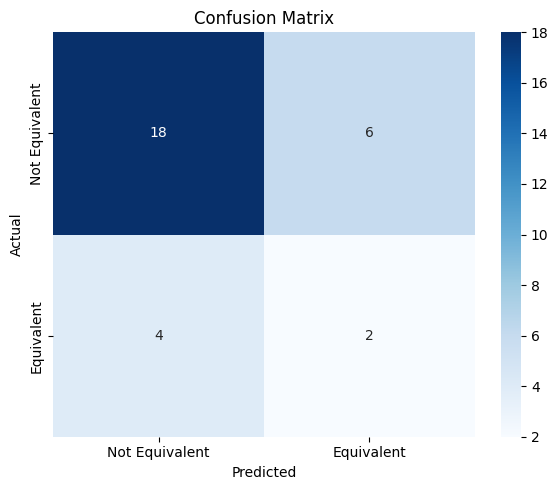

In [ ]:
#  Required Libraries
import os
import csv
import itertools
from collections import defaultdict
import pandas as pd
import openai
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


#  Set your OpenAI API key
openai.api_key = 'API KEY'  # <-- Put your key here

##  Correct root folder path
data_dir = "/content/extracted_data/partitioned_results_TFTPWMN1Complete"

code_db = []
code_lookup = {}
pairwise = []
mutant_id_to_set = {}
set_to_ids = defaultdict(list)

# Step 1: Generate code_db.csv
for set_folder in sorted(os.listdir(data_dir)):
    set_path = os.path.join(data_dir, set_folder)
    if not os.path.isdir(set_path):
        continue

    for file in os.listdir(set_path):
        if file.endswith(".java") and file.startswith("M"):
            try:
                code_id = int(file[1:-5])  # Remove 'M' and '.java'
            except:
                continue  # Skip malformed filenames
            file_path = os.path.join(set_path, file)
            with open(file_path, "r", encoding="utf-8") as f:
                code = f.read().strip()
            if code:  # Skip empty files
                code_db.append({"id": code_id, "code": code})
                code_lookup[code_id] = code
                mutant_id_to_set[code_id] = set_folder
                set_to_ids[set_folder].append(code_id)

# Step 2: Generate pairwise equivalence data
pair_id = 0

# (a) Add all equivalent pairs (same set)
for mutant_ids in set_to_ids.values():
    for combo in itertools.combinations(mutant_ids, 2):
        pairwise.append({
            "id": pair_id,
            "code_id_1": combo[0],
            "code_id_2": combo[1],
            "label": 1
        })
        pair_id += 1

# (b) Add non-equivalent pairs (from different sets)
all_sets = list(set_to_ids.keys())
for i in range(len(all_sets)):
    for j in range(i + 1, len(all_sets)):
        set_i = all_sets[i]
        set_j = all_sets[j]
        for id_i in set_to_ids[set_i]:
            for id_j in set_to_ids[set_j]:
                pairwise.append({
                    "id": pair_id,
                    "code_id_1": id_i,
                    "code_id_2": id_j,
                    "label": 0
                })
                pair_id += 1

# Step 3: Save code_db.csv
code_df = pd.DataFrame(code_db)
code_df.to_csv("code_db.csv", index=False)

# Step 4: Save pairwise.csv
pair_df = pd.DataFrame(pairwise)
pair_df.to_csv("pairwise.csv", index=False)

# Step 5: Merge into GPT-4 input format
merged = pair_df.merge(code_df.rename(columns={"id": "code_id_1", "code": "mutant1"}), on="code_id_1")
merged = merged.merge(code_df.rename(columns={"id": "code_id_2", "code": "mutant2"}), on="code_id_2")

final_df = merged.rename(columns={"label": "equivalent"})

# Save for GPT-4 prediction
final_df.to_csv("generated_mutant_pairs.csv", index=False)

print(" All files generated: code_db.csv, pairwise.csv, generated_mutant_pairs.csv")
print(f" Total Pairs: {len(final_df)}")
print(final_df.head())

# Limit to a sample (e.g., 25) for GPT testing
sample_df = final_df.sample(n=30, random_state=42).reset_index(drop=True)
#few_shots = sample_balanced_few_shots(sample_df, i, n=2)


#  Format few-shot examples
def format_example(mutant1, mutant2, equivalent):
    label = "Equivalent" if equivalent == 1 else "Not Equivalent"
    return (
        f"Mutant 1:\n{truncate_code(mutant1)}\n\n"
        f"Mutant 2:\n{truncate_code(mutant2)}\n\n"
        f"Are they equivalent? Answer: {label}\n\n"
    )

def sample_balanced_few_shots(df, test_index, n=10):
    df = df.drop(index=test_index)
    if df['equivalent'].nunique() < 2:
        return df.sample(n=n, random_state=42)
    pos = df[df['equivalent'] == 1].sample(n=n, random_state=42)
    neg = df[df['equivalent'] == 0].sample(n=n, random_state=42)
    return pd.concat([pos, neg])

def build_prompt(few_shots, test_row):
    intro = (
        "You are a code analysis assistant. You will be given two versions of a Java function. "
        "Your job is to determine if the two versions are semantically equivalent — meaning they perform the same logic "
        "and will always return the same result for the same input.\n\n"
        "Respond only with 'Equivalent' or 'Not Equivalent'.\n\n"
        "try to get diverse classification dont classify everything as 0 or everything as 1, i know its hard because the data is imbalanced but please try your hardes to understand the semnatics.\n\n"
    )
    examples = ''.join([
        format_example(row['mutant1'], row['mutant2'], row['equivalent'])
        for _, row in few_shots.iterrows()
    ])
    test = f"Mutant 1:\n{truncate_code(test_row['mutant1'])}\n\nMutant 2:\n{truncate_code(test_row['mutant2'])}\n\nAre they equivalent? Answer:"
    return intro + examples + test

def gpt4_predict(prompt):
    try:
        response = openai.chat.completions.create(
            model="gpt-3.5-turbo",
            messages=[
                {"role": "system", "content": "You are a helpful assistant that understands Java code."},
                {"role": "user", "content": prompt}
            ],
            temperature=0
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        print(f" GPT-3.5-turbo error: {e}")
        return "error"


def truncate_code(code, max_lines=30):
    lines = code.strip().split('\n')
    return '\n'.join(lines[:max_lines]) + ("\n..." if len(lines) > max_lines else "")




#  Evaluate model
predictions, actuals = [], []

for i, row in sample_df.iterrows():

    few_shots = sample_balanced_few_shots(sample_df, i, n=3)
    prompt = build_prompt(few_shots, row)

    print(f"\nTesting pair ID {row['id']}")
    response = gpt4_predict(prompt)
    print(" GPT-3.5-turbo Response:", response)

    if "not equivalent" in response.lower():
        pred = 0
    elif "equivalent" in response.lower():
        pred = 1
    else:
        pred = 0  # fallback/default

    actual = row["equivalent"]
    predictions.append(pred)
    actuals.append(actual)

    print(f" Actual: {actual} | Predicted: {pred}")
    time.sleep(1.5)

#  Evaluation Metrics
print("\n GPT-3.5-turbo Evaluation Metrics:")
print(f"Accuracy:  {accuracy_score(actuals, predictions):.4f}")
print(f"Precision: {precision_score(actuals, predictions, zero_division=0):.4f}")
print(f"Recall:    {recall_score(actuals, predictions, zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(actuals, predictions, zero_division=0):.4f}")

#  Confusion Matrix
cm = confusion_matrix(actuals, predictions)
labels = ['Not Equivalent', 'Equivalent']

print("\n Confusion Matrix:")
print(cm)

# Plot confusion matrix as heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


